# 4. Convergencia Sigma (σ)

Este notebook analiza si los países se vuelven más **parecidos** entre sí
en términos de nivel de desarrollo.

**Concepto clave**: Mientras que la convergencia beta pregunta
"¿los pobres crecen más rápido?", la convergencia sigma pregunta
"¿la brecha entre ricos y pobres se reduce?"

**Fórmula**: Para cada año, calculamos la desviación estándar del
logaritmo natural del PIB per cápita de todos los países analizados.

```
σ(t) = desv_estándar[ln(PIBpc₁), ln(PIBpc₂), ..., ln(PIBpcₙ)]
```

| Evolución de σ | Interpretación |
|----------------|--------------|
| σ disminuye con el tiempo | ✅ Convergencia sigma: los países se parecen más |
| σ aumenta con el tiempo | ❌ Divergencia sigma: los países se diferencian más |
| σ estable | → Estancamiento: no hay cambio en la dispersión |

**Importante**: La convergencia sigma puede bajar por dos razones:
1. Los pobres crecen más rápido (convergencia real) ✅
2. Los ricos crecen más lento o estancan (divergencia por abajo) ⚠️

Por eso se analiza **junto con** la convergencia beta.


In [3]:
import sys
import os

# Detectar src/ automáticamente: sube desde notebooks/v1.0/ → raíz del proyecto
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
SRC_PATH = os.path.join(PROJECT_ROOT, "src")

sys.path.insert(0, SRC_PATH)

print(f"Project root: {PROJECT_ROOT}")
print(f"src: {SRC_PATH}")
print(f"Existe: {os.path.exists(os.path.join(SRC_PATH, 'config.py'))}")

from config import UE14, V4, COLORES_V4, NOMBRES_PAIS, AÑO_INICIO_DEFAULT, AÑO_FIN_DEFAULT
from db_utils import load_convergencia_data
from plotting_utils import setup_plot_style, save_figure

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

setup_plot_style()
print("✅ Todo listo")

Project root: /Users/raulrivera/Desktop/1-Data/Data Analyst Projects/poland_data2
src: /Users/raulrivera/Desktop/1-Data/Data Analyst Projects/poland_data2/src
Existe: True
✅ Todo listo


In [4]:
# Cargar datos de todos los países (V4 + UE-14)
df = load_convergencia_data(paises=UE14 + V4, años=list(range(AÑO_INICIO_DEFAULT, AÑO_FIN_DEFAULT + 1)))

# Calcular sigma para cada año
sigma_años = []
for año in sorted(df['año'].unique()):
    valores_año = df[df['año'] == año]['valor'].values
    if len(valores_año) > 0:
        ln_valores = np.log(valores_año)
        sigma = np.std(ln_valores)
        sigma_años.append({'año': año, 'sigma': sigma})

sigma_df = pd.DataFrame(sigma_años)

print("Evolución de σ (desviación estándar del log PIBpc):")
print(sigma_df.round(4).to_string(index=False))

Evolución de σ (desviación estándar del log PIBpc):
 año  sigma
2004 0.3654
2005 0.3614
2006 0.3744
2007 0.3601
2008 0.3468
2009 0.3159
2010 0.3335
2011 0.3344
2012 0.3408
2013 0.3384
2014 0.3374
2015 0.3525
2016 0.3521
2017 0.3520
2018 0.3460
2019 0.3344
2020 0.3513
2021 0.3609
2022 0.3589
2023 0.3352


In [5]:

# Estadísticas de cambio
sigma_inicial = sigma_df['sigma'].iloc[0]
sigma_final = sigma_df['sigma'].iloc[-1]
cambio_sigma = sigma_final - sigma_inicial
cambio_pct = (cambio_sigma / sigma_inicial) * 100

print(f"📊 Sigma inicial (2004): {sigma_inicial:.4f}")
print(f"   Sigma final (2023): {sigma_final:.4f}")
print(f"   Cambio absoluto: {cambio_sigma:.4f}")
print(f"   Cambio porcentual: {cambio_pct:.1f}%")
print()

if cambio_sigma < 0:
    print("✅ CONCLUSIÓN: σ disminuyó → EXISTE convergencia sigma La dispersión entre países se redujo.    Los países se parecen más en nivel de desarrollo.")
elif cambio_sigma > 0:
    print("❌ CONCLUSIÓN: σ aumentó → NO hay convergencia sigma La dispersión entre países creció. Los países se diferencian más.")
else:
    print("→ CONCLUSIÓN: σ estable → No hay cambio en la dispersión")

📊 Sigma inicial (2004): 0.3654
   Sigma final (2023): 0.3352
   Cambio absoluto: -0.0302
   Cambio porcentual: -8.3%

✅ CONCLUSIÓN: σ disminuyó → EXISTE convergencia sigma La dispersión entre países se redujo.    Los países se parecen más en nivel de desarrollo.


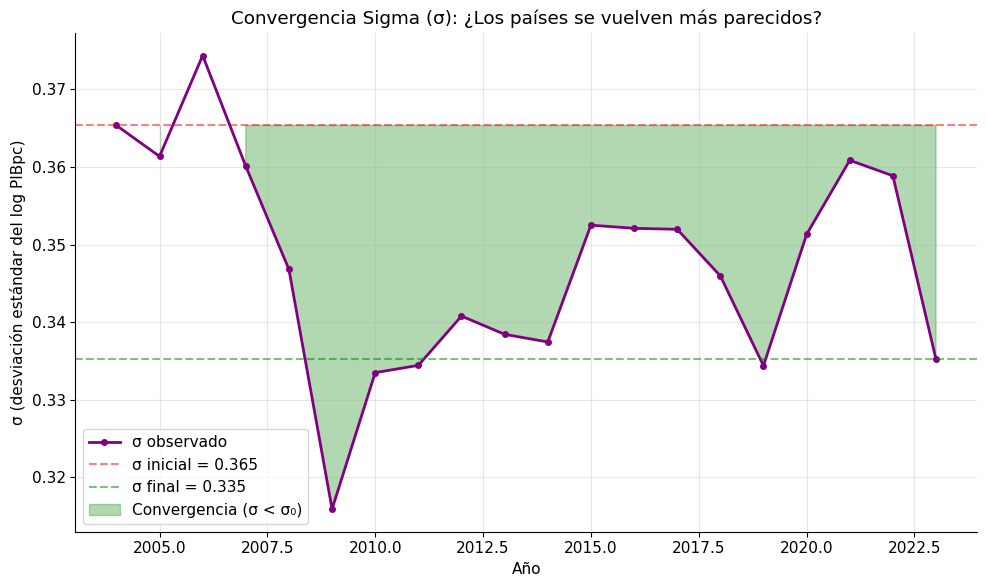

In [6]:
# Gráfica de convergencia sigma
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(sigma_df['año'], sigma_df['sigma'], 
        color='purple', linewidth=2, marker='o', markersize=4, label='σ observado')

ax.axhline(y=sigma_inicial, color='red', linestyle='--', alpha=0.5, 
           label=f'σ inicial = {sigma_inicial:.3f}')
ax.axhline(y=sigma_final, color='green', linestyle='--', alpha=0.5, 
           label=f'σ final = {sigma_final:.3f}')
            
 # Rellenar área de convergencia
ax.fill_between(sigma_df['año'], sigma_df['sigma'], sigma_inicial,
                where=(sigma_df['sigma'] < sigma_inicial),
                alpha=0.3, color='green', label='Convergencia (σ < σ₀)')

ax.set_title('Convergencia Sigma (σ): ¿Los países se vuelven más parecidos?')
ax.set_xlabel('Año')
ax.set_ylabel('σ (desviación estándar del log PIBpc)')
ax.legend()

plt.tight_layout()
save_figure(fig, '04_convergencia_sigma.png')
plt.show()

## Interpretación del gráfico

- **Línea púrpura**: La dispersión real entre países en cada año.
- **Línea roja punteada**: Dispersión inicial (2004). Es nuestra "línea de base".
- **Línea verde punteada**: Dispersión final (2023).
- **Área verde**: Períodos donde la dispersión está por debajo de la inicial.
  Mientras más verde, más convergencia sigma.

**Analogía**: Imagina que todos los países corren una maratón.
- Si σ baja: los corredores se agrupan (unos aceleran, otros desaceleran).
- Si σ sube: los corredores se dispersan (algunos aceleran mucho, otros se quedan).

**Nota**: Convergencia sigma y beta son complementarias:
- Beta nos dice **quién** crece más rápido (los pobres).
- Sigma nos dice si **todos** se acercan (dispersión global).